# Housing Prices Competition for Kaggle Learn Users

In [1]:
import warnings
warnings.filterwarnings("ignore")
 
import numpy as np
import pandas as pd
 
import matplotlib.pyplot as plt
import seaborn as sns
 
from scipy import stats
from scipy.stats import skew, norm
 
from sklearn.model_selection import KFold, cross_val_score, train_test_split
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, StackingRegressor
from sklearn.metrics import mean_squared_error
 
try:
    from xgboost import XGBRegressor
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
 
try:
    from lightgbm import LGBMRegressor
    HAS_LGBM = True
except ImportError:
    HAS_LGBM = False
 
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
pd.set_option("display.max_columns", 100)
 
RANDOM_STATE = 42
 

In [2]:
DATA_DIR = "./data"
 
train = pd.read_csv(f"{DATA_DIR}/train.csv")
test = pd.read_csv(f"{DATA_DIR}/test.csv")
 
print("Train shape:", train.shape)
print("Test shape :", test.shape)
 
train.head()
 
 

Train shape: (1460, 81)
Test shape : (1459, 80)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [3]:
train_ID = train["Id"]
test_ID = test["Id"]
 
train.drop("Id", axis=1, inplace=True)
test.drop("Id", axis=1, inplace=True)
 
train.describe().T

,count,mean,std,min,25%,50%,75%,max
MSSubClass,1460.0,56.897260,42.300571,20.0,20.00,50.0,70.00,190.0
LotFrontage,1201.0,70.049958,24.284752,21.0,59.00,69.0,80.00,313.0
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.5,11601.50,215245.0
OverallQual,1460.0,6.099315,1.382997,1.0,5.00,6.0,7.00,10.0
OverallCond,1460.0,5.575342,1.112799,1.0,5.00,5.0,6.00,9.0
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1954.00,1973.0,2000.00,2010.0
YearRemodAdd,1460.0,1984.865753,20.645407,1950.0,1967.00,1994.0,2004.00,2010.0
MasVnrArea,1452.0,103.685262,181.066207,0.0,0.00,0.0,166.00,1600.0
BsmtFinSF1,1460.0,443.639726,456.098091,0.0,0.00,383.5,712.25,5644.0
BsmtFinSF2,1460.0,46.549315,161.319273,0.0,0.00,0.0,0.00,1474.0


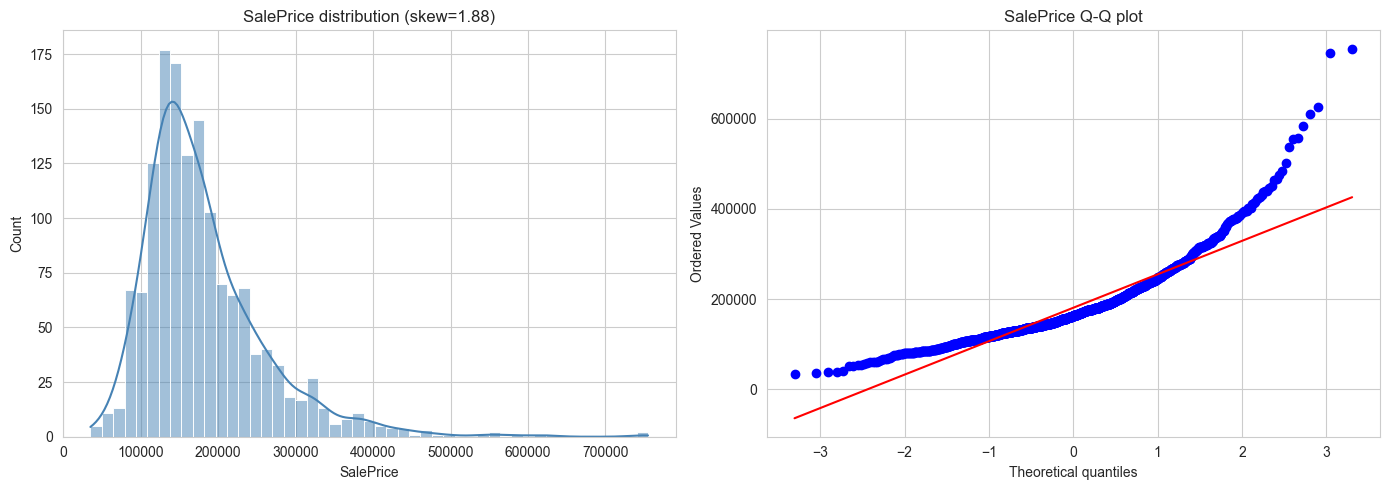

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
sns.histplot(train["SalePrice"], kde=True, ax=axes[0], color="steelblue")
axes[0].set_title(f"SalePrice distribution (skew={skew(train['SalePrice']):.2f})")
 
stats.probplot(train["SalePrice"], plot=axes[1])
axes[1].set_title("SalePrice Q-Q plot")
 
plt.tight_layout()
plt.show()

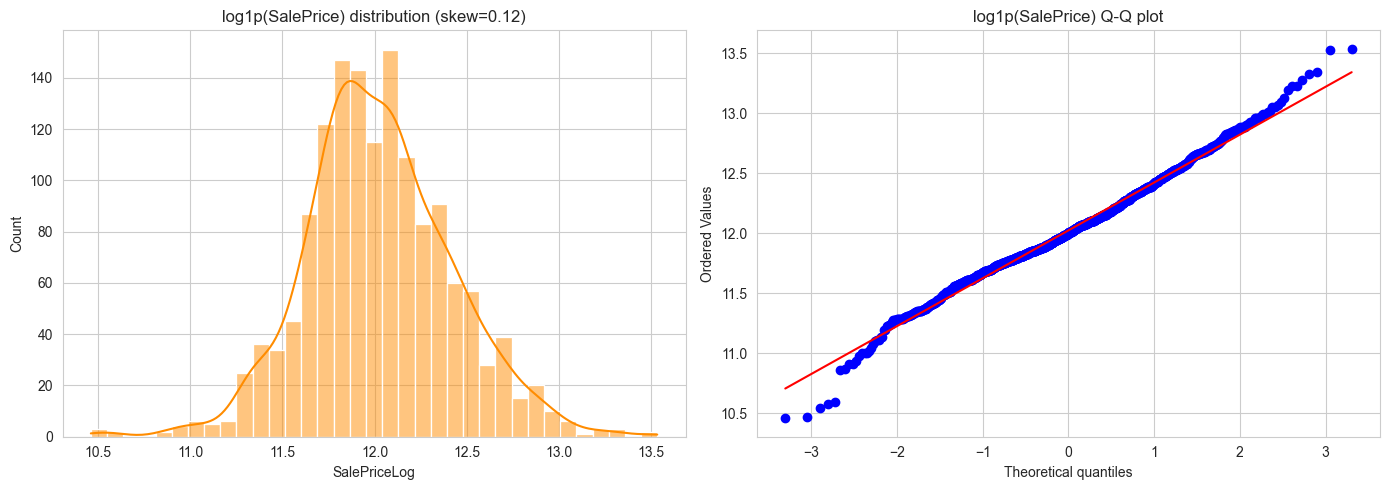

In [5]:
train["SalePriceLog"] = np.log1p(train["SalePrice"])
 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
sns.histplot(train["SalePriceLog"], kde=True, ax=axes[0], color="darkorange")
axes[0].set_title(f"log1p(SalePrice) distribution (skew={skew(train['SalePriceLog']):.2f})")
 
stats.probplot(train["SalePriceLog"], plot=axes[1])
axes[1].set_title("log1p(SalePrice) Q-Q plot")
 
plt.tight_layout()
plt.show()

In [6]:
def missing_table(df):
    total = df.isnull().sum()
    pct = (total / len(df)) * 100
    tbl = pd.concat([total, pct], axis=1, keys=["Total", "Percent"])
    return tbl[tbl["Total"] > 0].sort_values("Percent", ascending=False)
 
missing_train = missing_table(train)
missing_train

,Total,Percent
PoolQC,1453,99.520548
MiscFeature,1406,96.301370
Alley,1369,93.767123
Fence,1179,80.753425
MasVnrType,872,59.726027
FireplaceQu,690,47.260274
LotFrontage,259,17.739726
GarageType,81,5.547945
GarageYrBlt,81,5.547945
GarageFinish,81,5.547945


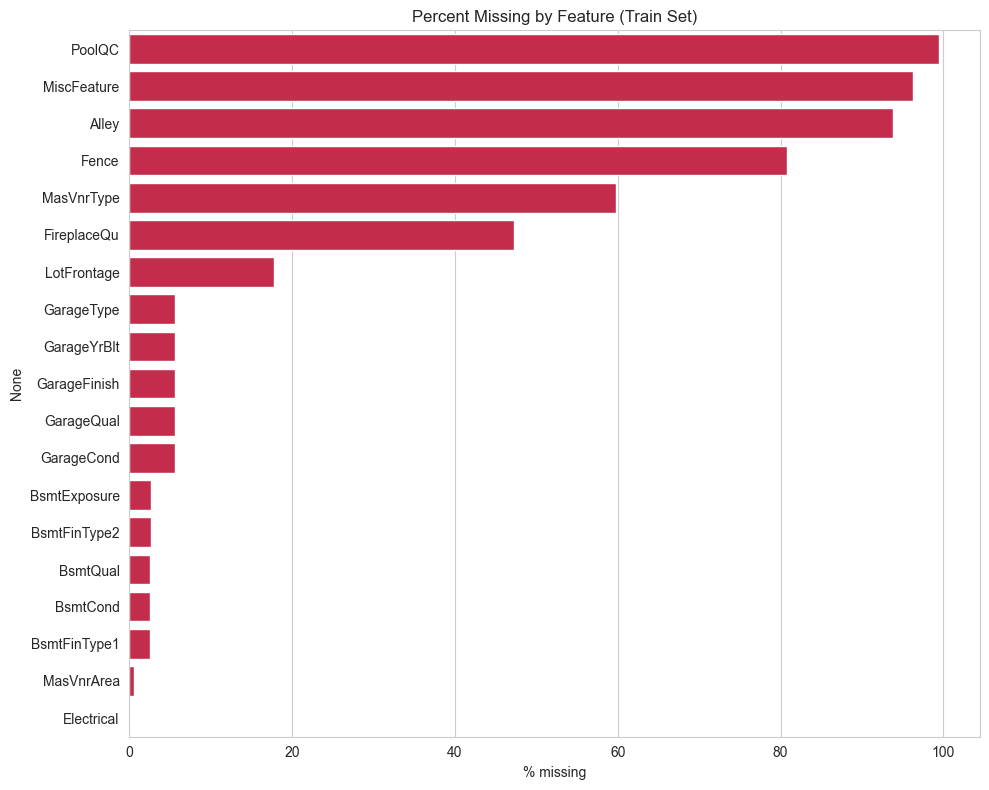

In [7]:
plt.figure(figsize=(10, 8))
sns.barplot(x=missing_train["Percent"], y=missing_train.index, color="crimson")
plt.title("Percent Missing by Feature (Train Set)")
plt.xlabel("% missing")
plt.tight_layout()
plt.show()

In [8]:
numeric_feats = train.select_dtypes(include=[np.number]).columns.tolist()
numeric_feats = [c for c in numeric_feats if c not in ("SalePrice", "SalePriceLog")]
 
corr_with_target = train[numeric_feats + ["SalePrice"]].corr()["SalePrice"].drop("SalePrice")
top_corr_feats = corr_with_target.abs().sort_values(ascending=False).head(9).index.tolist()
top_corr_feats

['OverallQual',
 'GrLivArea',
 'GarageCars',
 'GarageArea',
 'TotalBsmtSF',
 '1stFlrSF',
 'FullBath',
 'TotRmsAbvGrd',
 'YearBuilt']

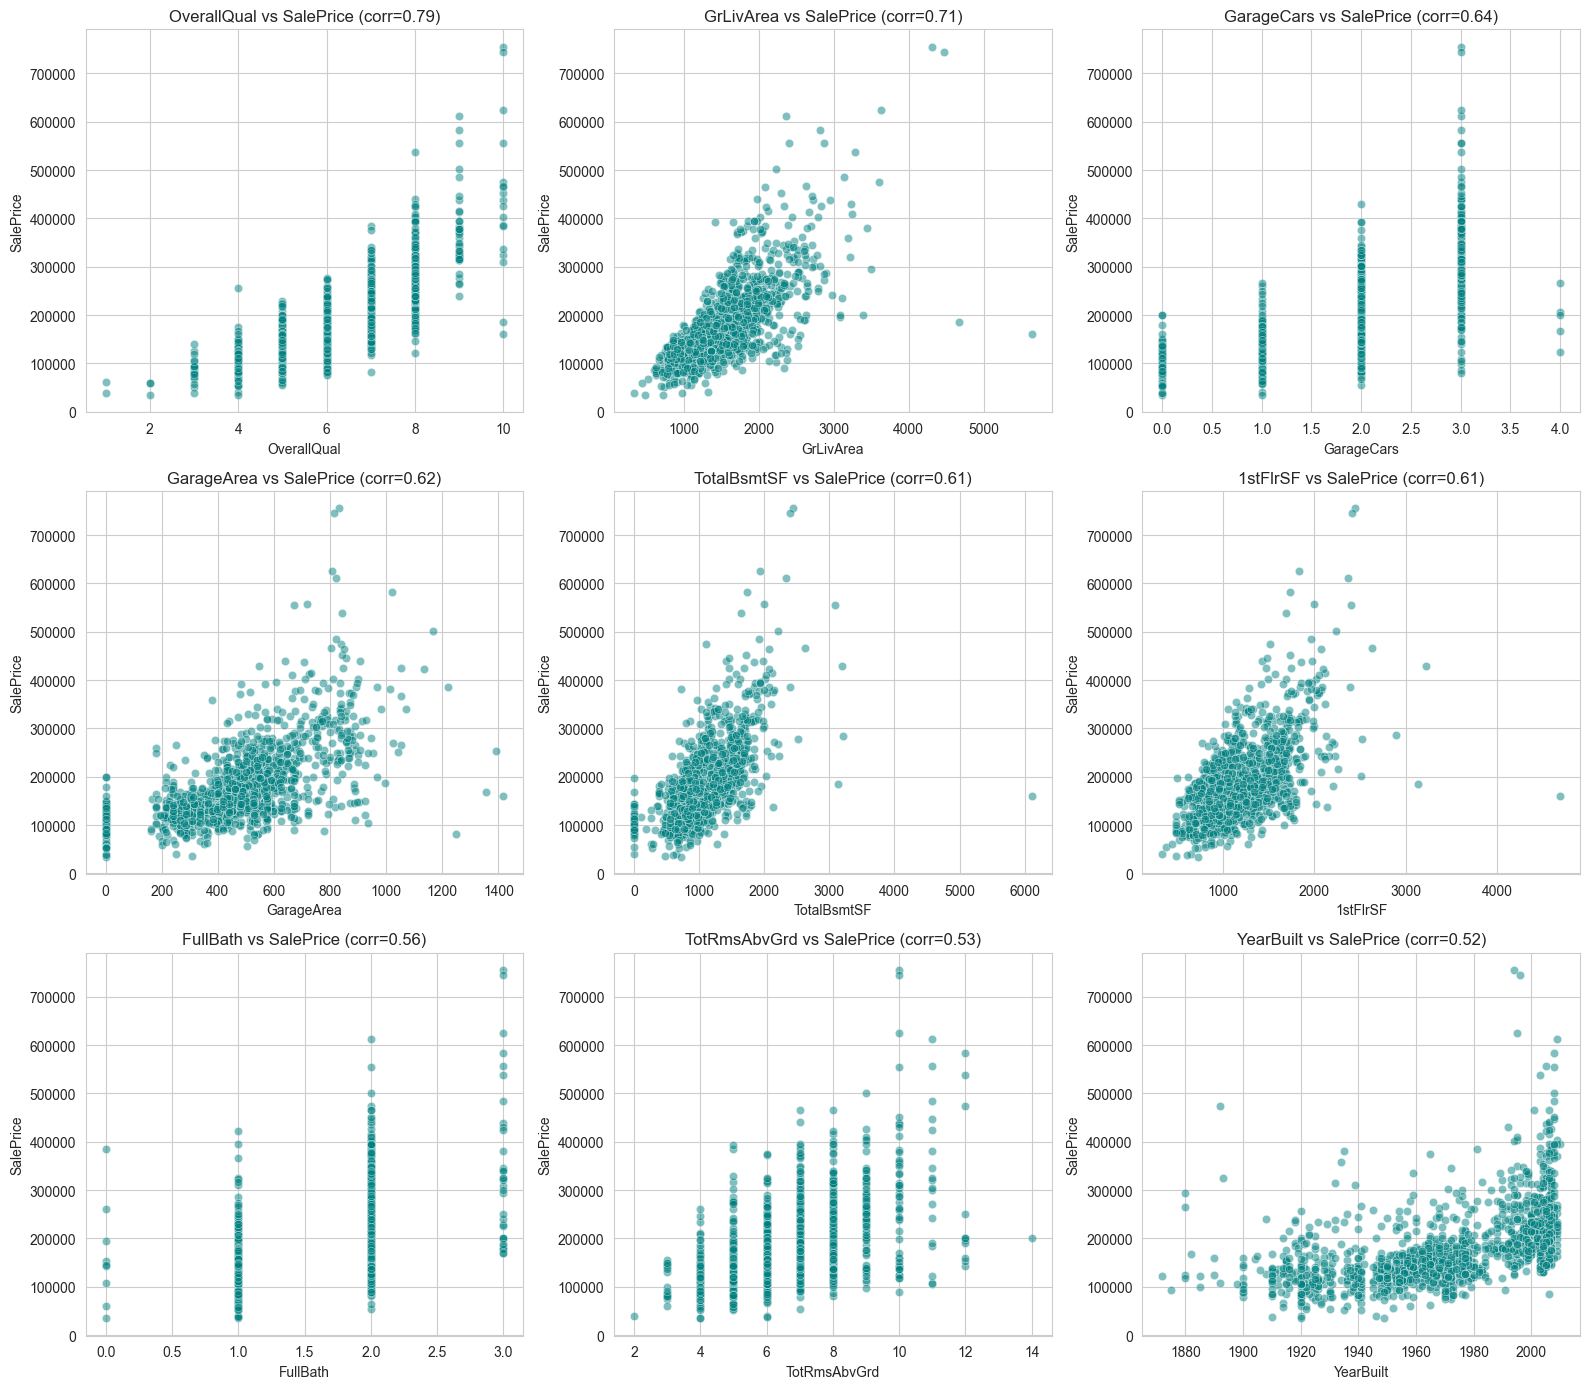

In [9]:
fig, axes = plt.subplots(3, 3, figsize=(16, 14))
axes = axes.flatten()
 
for i, feat in enumerate(top_corr_feats):
    sns.scatterplot(x=train[feat], y=train["SalePrice"], ax=axes[i], alpha=0.5, color="teal")
    axes[i].set_title(f"{feat} vs SalePrice (corr={corr_with_target[feat]:.2f})")
 
plt.tight_layout()
plt.show()

In [10]:
outliers = train[(train["GrLivArea"] > 4000) & (train["SalePrice"] < 300000)]
print(f"Outliers identified: {len(outliers)}")
outliers[["GrLivArea", "TotalBsmtSF", "SalePrice"]]

Outliers identified: 2


,GrLivArea,TotalBsmtSF,SalePrice
523,4676,3138,184750
1298,5642,6110,160000


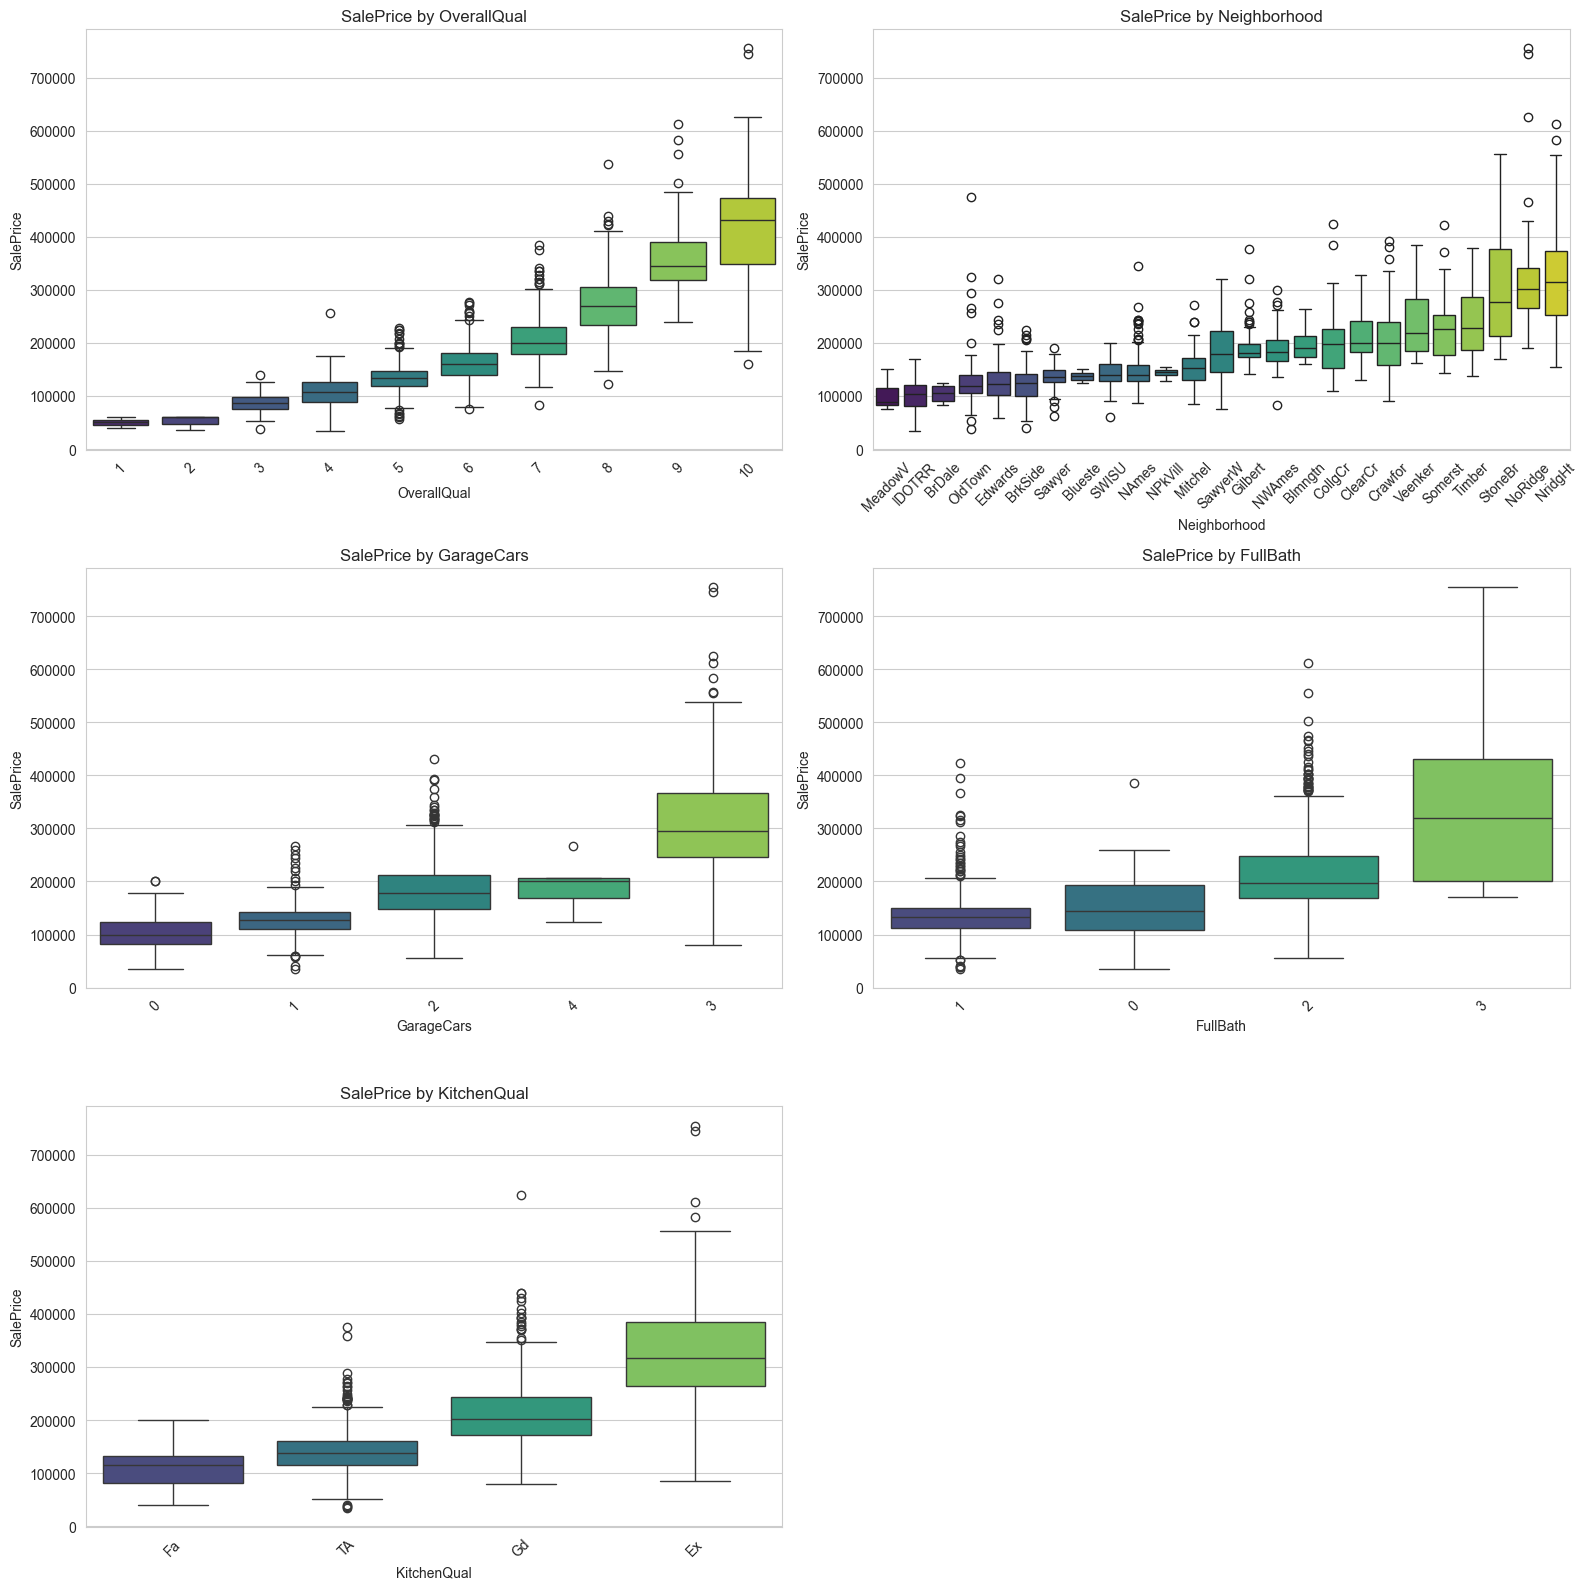

In [11]:
cat_feats_of_interest = ["OverallQual", "Neighborhood", "GarageCars", "FullBath", "KitchenQual"]
 
fig, axes = plt.subplots(3, 2, figsize=(16, 16))
axes = axes.flatten()
 
for i, feat in enumerate(cat_feats_of_interest):
    order = train.groupby(feat)["SalePrice"].median().sort_values().index
    sns.boxplot(x=feat, y="SalePrice", data=train, order=order, ax=axes[i], palette="viridis")
    axes[i].set_title(f"SalePrice by {feat}")
    axes[i].tick_params(axis="x", rotation=45)
 
axes[-1].axis("off")
plt.tight_layout()
plt.show()

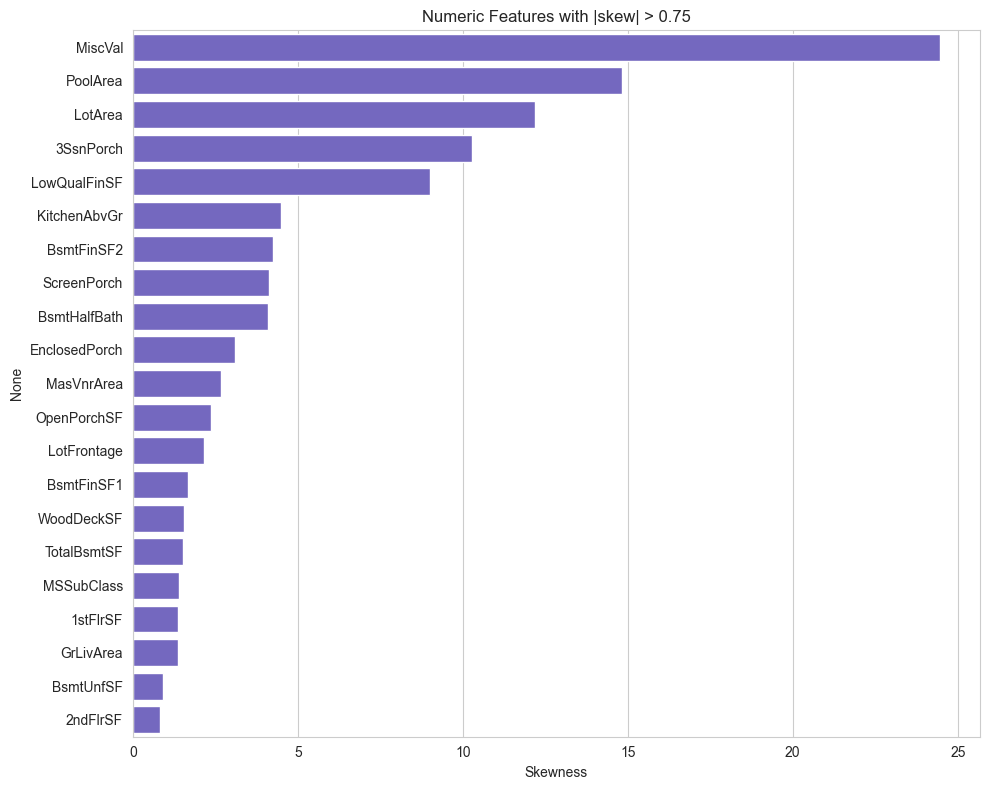

In [12]:
skewed = train[numeric_feats].apply(lambda x: skew(x.dropna())).sort_values(ascending=False)
skewed_top = skewed[abs(skewed) > 0.75]
 
plt.figure(figsize=(10, 8))
sns.barplot(x=skewed_top.values, y=skewed_top.index, color="slateblue")
plt.title("Numeric Features with |skew| > 0.75")
plt.xlabel("Skewness")
plt.tight_layout()
plt.show()

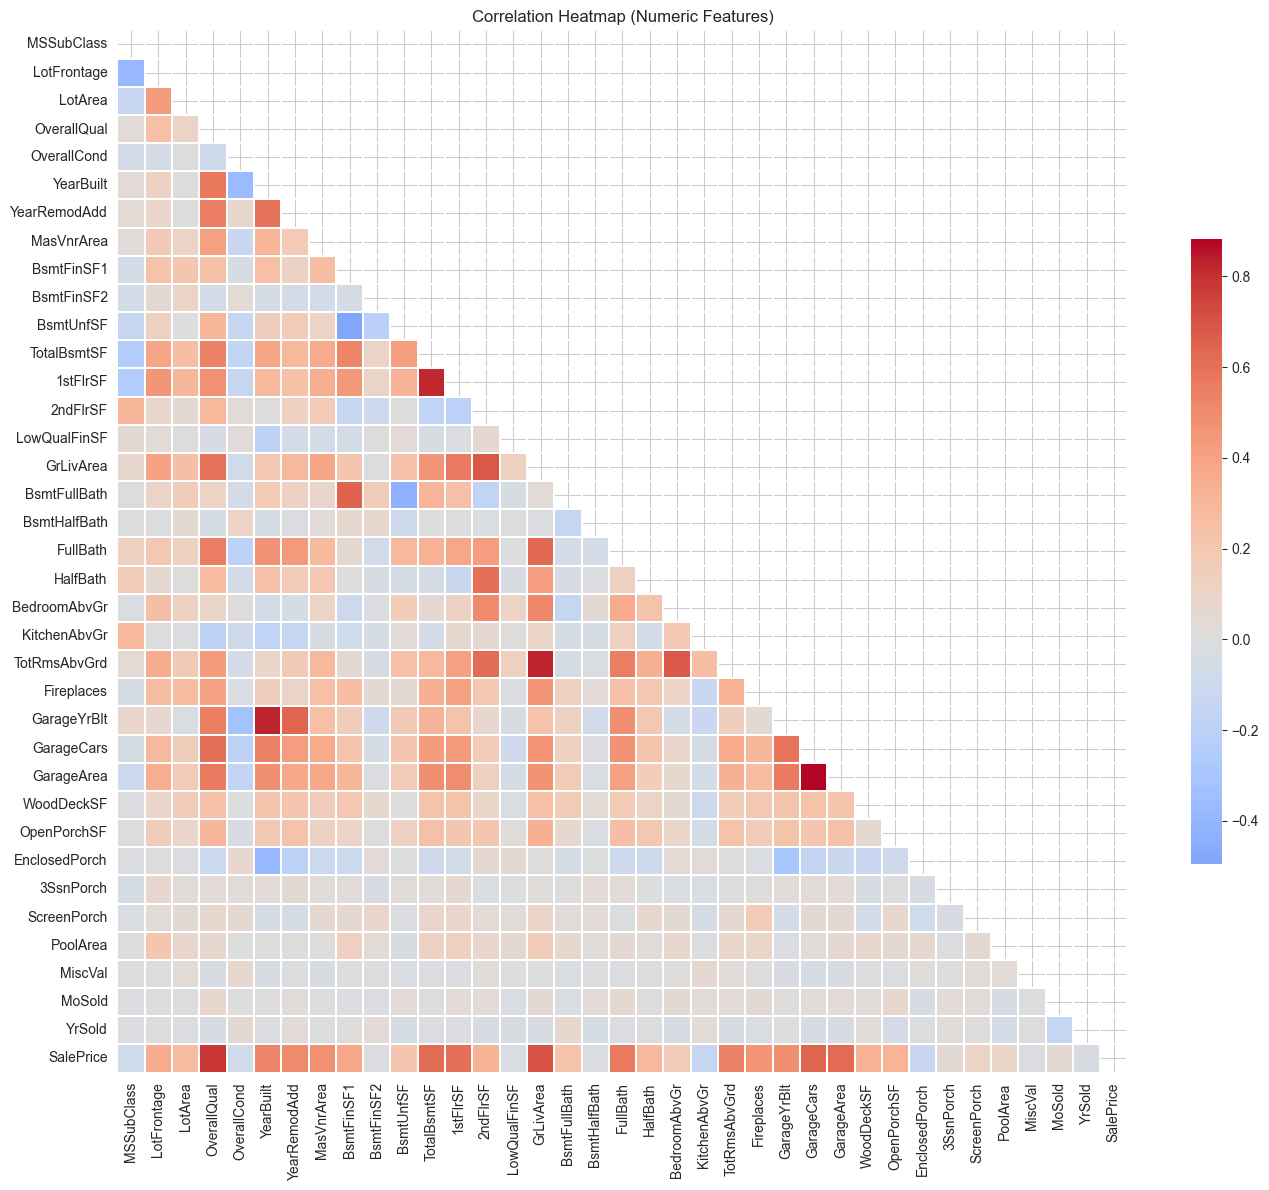

In [13]:
plt.figure(figsize=(14, 12))
corr_matrix = train[numeric_feats + ["SalePrice"]].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, cmap="coolwarm", center=0, linewidths=0.3,
            cbar_kws={"shrink": 0.6})
plt.title("Correlation Heatmap (Numeric Features)")
plt.tight_layout()
plt.show()

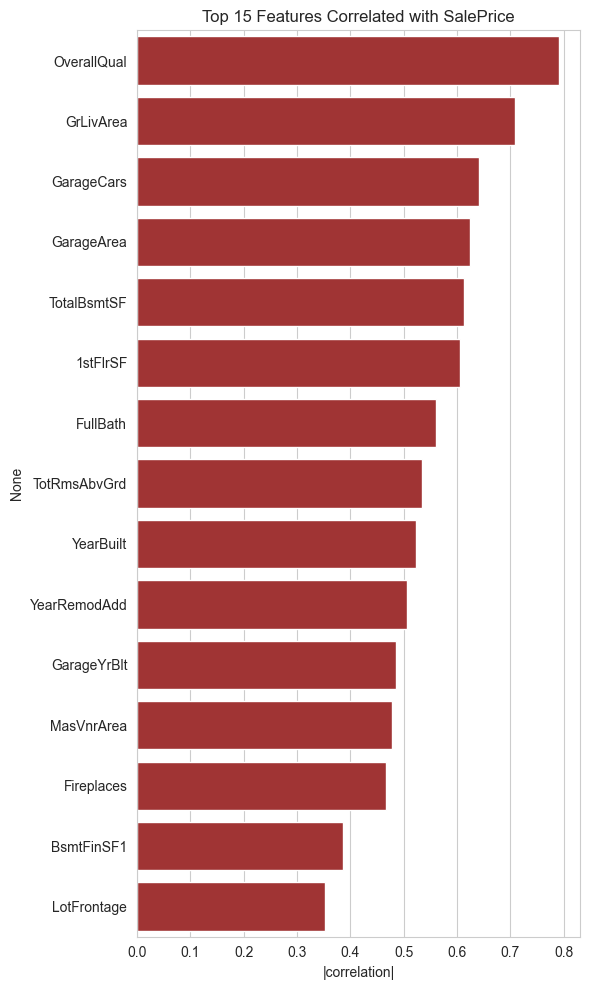

In [14]:
plt.figure(figsize=(6, 10))
top15 = corr_with_target.abs().sort_values(ascending=False).head(15)
sns.barplot(x=top15.values, y=top15.index, color="firebrick")
plt.title("Top 15 Features Correlated with SalePrice")
plt.xlabel("|correlation|")
plt.tight_layout()
plt.show()

In [15]:
train = train.drop(outliers.index)
 
y_train = train["SalePriceLog"].reset_index(drop=True)
train_features = train.drop(["SalePrice", "SalePriceLog"], axis=1)
 
n_train = train_features.shape[0]
all_data = pd.concat([train_features, test], axis=0).reset_index(drop=True)
print("Combined shape:", all_data.shape)

Combined shape: (2917, 79)


In [16]:
none_cols = ["PoolQC", "MiscFeature", "Alley", "Fence", "FireplaceQu",
             "GarageType", "GarageFinish", "GarageQual", "GarageCond",
             "BsmtQual", "BsmtCond", "BsmtExposure", "BsmtFinType1", "BsmtFinType2",
             "MasVnrType"]
for col in none_cols:
    all_data[col] = all_data[col].fillna("None")
 
# Numeric features where NaN means "0" (e.g. no garage -> 0 garage area)
zero_cols = ["GarageYrBlt", "GarageArea", "GarageCars",
             "BsmtFinSF1", "BsmtFinSF2", "BsmtUnfSF", "TotalBsmtSF",
             "BsmtFullBath", "BsmtHalfBath", "MasVnrArea"]
for col in zero_cols:
    all_data[col] = all_data[col].fillna(0)
 
# LotFrontage: impute using the median within each Neighborhood
all_data["LotFrontage"] = all_data.groupby("Neighborhood")["LotFrontage"] \
    .transform(lambda x: x.fillna(x.median()))
 
# A handful of columns with only a few missing values: fill with the mode
mode_cols = ["MSZoning", "Electrical", "KitchenQual", "Exterior1st",
             "Exterior2nd", "SaleType", "Functional"]
for col in mode_cols:
    all_data[col] = all_data[col].fillna(all_data[col].mode()[0])
 
# Utilities is almost constant and not useful -- drop it
all_data.drop("Utilities", axis=1, inplace=True)
 
print("Remaining missing values:", all_data.isnull().sum().sum())

Remaining missing values: 0


In [17]:
all_data["TotalSF"] = all_data["TotalBsmtSF"] + all_data["1stFlrSF"] + all_data["2ndFlrSF"]
all_data["TotalBathrooms"] = (all_data["FullBath"] + 0.5 * all_data["HalfBath"] +
                              all_data["BsmtFullBath"] + 0.5 * all_data["BsmtHalfBath"])
all_data["TotalPorchSF"] = (all_data["OpenPorchSF"] + all_data["3SsnPorch"] +
                            all_data["EnclosedPorch"] + all_data["ScreenPorch"] +
                            all_data["WoodDeckSF"])
all_data["HouseAge"] = all_data["YrSold"] - all_data["YearBuilt"]
all_data["RemodAge"] = all_data["YrSold"] - all_data["YearRemodAdd"]
all_data["IsRemodeled"] = (all_data["YearBuilt"] != all_data["YearRemodAdd"]).astype(int)
all_data["HasPool"] = (all_data["PoolArea"] > 0).astype(int)
all_data["Has2ndFloor"] = (all_data["2ndFlrSF"] > 0).astype(int)
all_data["HasGarage"] = (all_data["GarageArea"] > 0).astype(int)
all_data["HasBsmt"] = (all_data["TotalBsmtSF"] > 0).astype(int)
all_data["HasFireplace"] = (all_data["Fireplaces"] > 0).astype(int)
 
# Some numeric-looking columns are really categories
for col in ["MSSubClass", "OverallCond", "YrSold", "MoSold"]:
    all_data[col] = all_data[col].astype(str)
 
print("Shape after feature engineering:", all_data.shape)

Shape after feature engineering: (2917, 89)


In [18]:
numeric_cols = all_data.select_dtypes(include=[np.number]).columns
skewed_feats = all_data[numeric_cols].apply(lambda x: skew(x.dropna())).sort_values(ascending=False)
high_skew = skewed_feats[abs(skewed_feats) > 0.75]
print(f"{len(high_skew)} numeric features are highly skewed, applying boxcox1p")
 
from scipy.special import boxcox1p
lam = 0.15
for feat in high_skew.index:
    all_data[feat] = boxcox1p(all_data[feat], lam)

25 numeric features are highly skewed, applying boxcox1p


In [19]:
all_data_encoded = pd.get_dummies(all_data)
print("Shape after one-hot encoding:", all_data_encoded.shape)
 
X_train_full = all_data_encoded.iloc[:n_train, :].reset_index(drop=True)
X_test_full = all_data_encoded.iloc[n_train:, :].reset_index(drop=True)
 
X_train_full.shape, X_test_full.shape, y_train.shape

Shape after one-hot encoding: (2917, 348)


((1458, 348), (1459, 348), (1458,))

In [20]:
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_full, y_train, test_size=0.2, random_state=RANDOM_STATE
)
 
scaler = RobustScaler()
X_tr_scaled = scaler.fit_transform(X_tr)
X_val_scaled = scaler.transform(X_val)
X_train_full_scaled = scaler.fit_transform(X_train_full)
X_test_full_scaled = scaler.transform(X_test_full)

In [21]:
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
 
def cv_rmse(model, X, y):
    scores = -cross_val_score(model, X, y, scoring="neg_root_mean_squared_error", cv=kf)
    return scores
 
models = {
    "Ridge": Ridge(alpha=10.0, random_state=RANDOM_STATE),
    "Lasso": Lasso(alpha=0.0005, random_state=RANDOM_STATE, max_iter=10000),
    "ElasticNet": ElasticNet(alpha=0.0005, l1_ratio=0.9, random_state=RANDOM_STATE, max_iter=10000),
    "RandomForest": RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1),
    "GradientBoosting": GradientBoostingRegressor(n_estimators=300, learning_rate=0.05,
                                                   max_depth=3, random_state=RANDOM_STATE),
}
 
if HAS_XGB:
    models["XGBoost"] = XGBRegressor(
        n_estimators=1000, learning_rate=0.03, max_depth=3,
        subsample=0.8, colsample_bytree=0.6, random_state=RANDOM_STATE, n_jobs=-1
    )
 
if HAS_LGBM:
    models["LightGBM"] = LGBMRegressor(
        n_estimators=1000, learning_rate=0.03, num_leaves=6,
        random_state=RANDOM_STATE, n_jobs=-1, verbose=-1
    )
 
results = {}
for name, model in models.items():
    X_in = X_train_full_scaled if name in ("Ridge", "Lasso", "ElasticNet") else X_train_full
    scores = cv_rmse(model, X_in, y_train)
    results[name] = scores
    print(f"{name:>18s}: RMSE = {scores.mean():.4f}  (+/- {scores.std():.4f})")
 

             Ridge: RMSE = 0.1129  (+/- 0.0086)
             Lasso: RMSE = 0.1108  (+/- 0.0076)
        ElasticNet: RMSE = 0.1108  (+/- 0.0077)
      RandomForest: RMSE = 0.1377  (+/- 0.0067)
  GradientBoosting: RMSE = 0.1242  (+/- 0.0056)


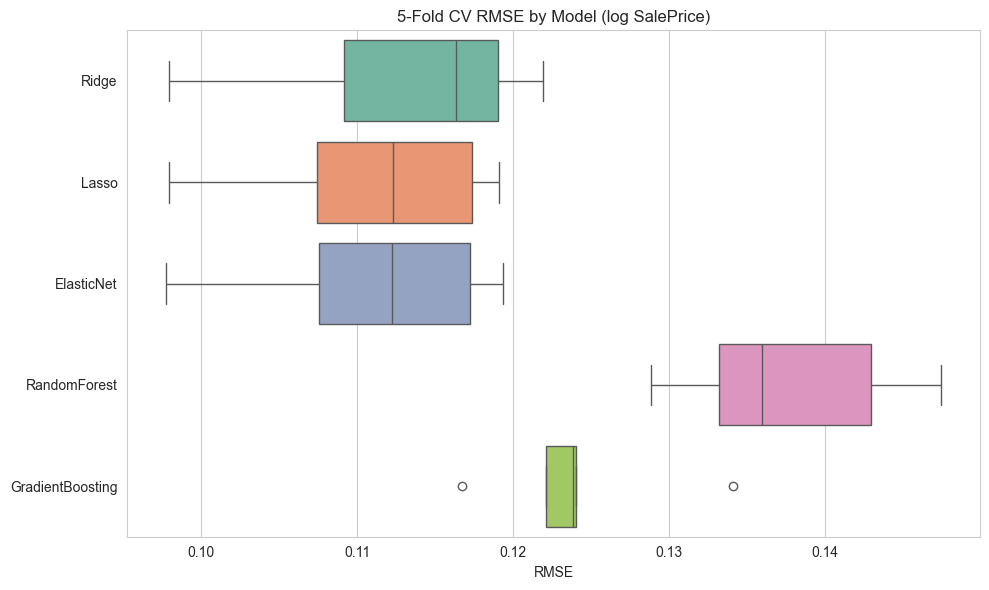

In [22]:
results_df = pd.DataFrame(results)
 
plt.figure(figsize=(10, 6))
sns.boxplot(data=results_df, orient="h", palette="Set2")
plt.title("5-Fold CV RMSE by Model (log SalePrice)")
plt.xlabel("RMSE")
plt.tight_layout()
plt.show()

In [23]:
final_ridge = Ridge(alpha=10.0, random_state=RANDOM_STATE)
final_lasso = Lasso(alpha=0.0005, random_state=RANDOM_STATE, max_iter=10000)
final_enet = ElasticNet(alpha=0.0005, l1_ratio=0.9, random_state=RANDOM_STATE, max_iter=10000)
final_gbr = GradientBoostingRegressor(
    n_estimators=3000, learning_rate=0.02, max_depth=4, max_features="sqrt",
    min_samples_leaf=15, min_samples_split=10, loss="huber", random_state=RANDOM_STATE
)
 
estimators = [
    ("ridge", final_ridge),
    ("lasso", final_lasso),
    ("enet", final_enet),
    ("gbr", final_gbr),
]
 
if HAS_XGB:
    estimators.append(("xgb", XGBRegressor(
        n_estimators=2000, learning_rate=0.02, max_depth=3,
        subsample=0.7, colsample_bytree=0.6, random_state=RANDOM_STATE, n_jobs=-1
    )))
if HAS_LGBM:
    estimators.append(("lgbm", LGBMRegressor(
        n_estimators=2000, learning_rate=0.02, num_leaves=5,
        random_state=RANDOM_STATE, n_jobs=-1, verbose=-1
    )))
 
estimators

[('ridge', Ridge(alpha=10.0, random_state=42)),
 ('lasso', Lasso(alpha=0.0005, max_iter=10000, random_state=42)),
 ('enet',
  ElasticNet(alpha=0.0005, l1_ratio=0.9, max_iter=10000, random_state=42)),
 ('gbr',
  GradientBoostingRegressor(learning_rate=0.02, loss='huber', max_depth=4,
                            max_features='sqrt', min_samples_leaf=15,
                            min_samples_split=10, n_estimators=3000,
                            random_state=42))]

In [24]:
for name, model in estimators:
    X_in_tr = X_tr_scaled if name in ("ridge", "lasso", "enet") else X_tr
    X_in_val = X_val_scaled if name in ("ridge", "lasso", "enet") else X_val
    model.fit(X_in_tr, y_tr)
    preds = model.predict(X_in_val)
    rmse = np.sqrt(mean_squared_error(y_val, preds))
    print(f"{name:>8s} validation RMSE: {rmse:.4f}")
 

   ridge validation RMSE: 0.1190
   lasso validation RMSE: 0.1123
    enet validation RMSE: 0.1122
     gbr validation RMSE: 0.1242


In [25]:
stack_estimators = [(name, model) for name, model in estimators]
 
stacked_model = StackingRegressor(
    estimators=stack_estimators,
    final_estimator=Ridge(alpha=1.0),
    cv=kf,
    n_jobs=-1,
)
 
stacked_model.fit(X_train_full_scaled, y_train)
stack_scores = cv_rmse(stacked_model, X_train_full_scaled, y_train)
print(f"Stacked ensemble CV RMSE: {stack_scores.mean():.4f}  (+/- {stack_scores.std():.4f})")
 

Stacked ensemble CV RMSE: 0.1084  (+/- 0.0090)


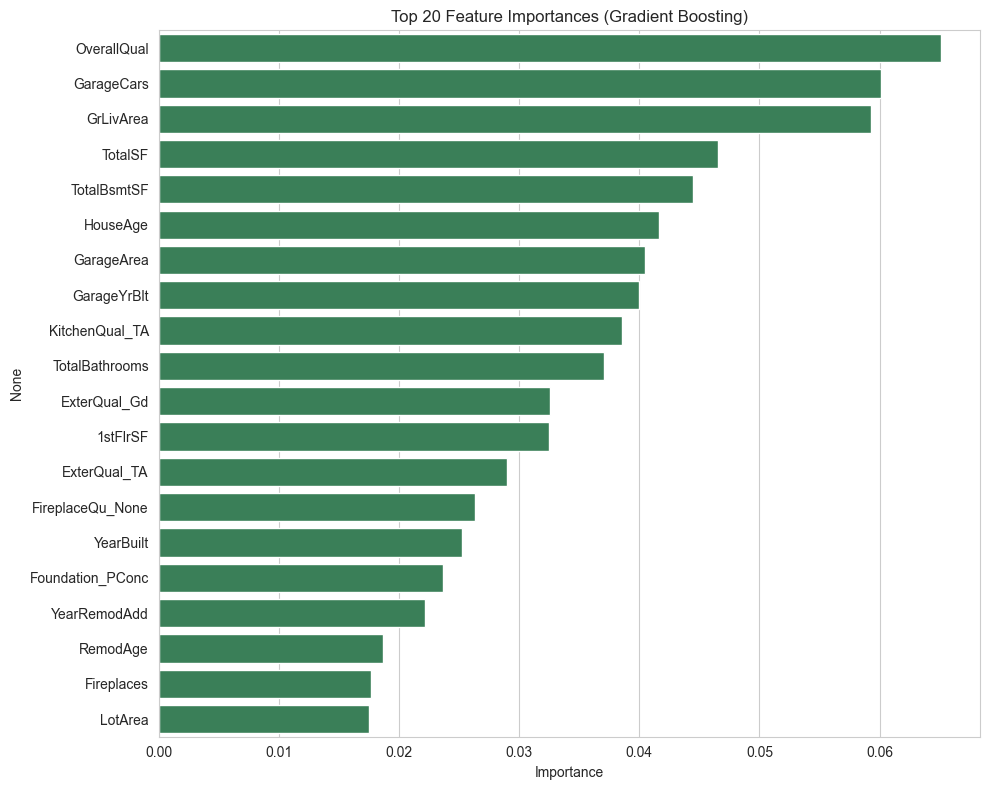

In [26]:
final_gbr.fit(X_train_full, y_train)
 
importances = pd.Series(final_gbr.feature_importances_, index=X_train_full.columns)
top_importances = importances.sort_values(ascending=False).head(20)
 
plt.figure(figsize=(10, 8))
sns.barplot(x=top_importances.values, y=top_importances.index, color="seagreen")
plt.title("Top 20 Feature Importances (Gradient Boosting)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

In [27]:
final_log_preds = stacked_model.predict(X_test_full_scaled)
final_preds = np.expm1(final_log_preds)  # inverse of log1p
 
submission = pd.DataFrame({
    "Id": test_ID,
    "SalePrice": final_preds
})
 
submission.to_csv("submission.csv", index=False)
submission.head()
 

,Id,SalePrice
0,1461,121262.512213
1,1462,155329.632718
2,1463,185373.566597
3,1464,199457.479862
4,1465,192970.875444


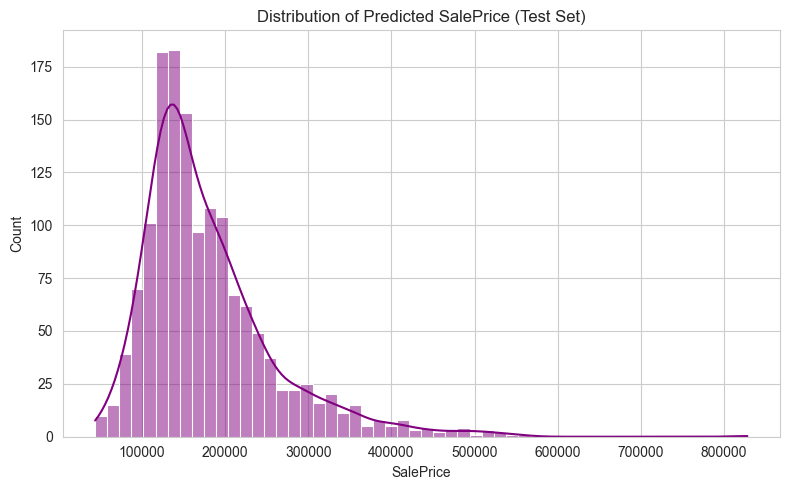

Saved predictions to submission.csv
count      1459.000000
mean     179217.043224
std       80205.393771
min       43650.450028
25%      126910.269768
50%      157291.593762
75%      210820.382797
max      828015.563021
Name: SalePrice, dtype: float64


In [28]:
plt.figure(figsize=(8, 5))
sns.histplot(submission["SalePrice"], kde=True, color="purple")
plt.title("Distribution of Predicted SalePrice (Test Set)")
plt.tight_layout()
plt.show()
 
print("Saved predictions to submission.csv")
print(submission["SalePrice"].describe())
 